In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-batches-py/test_batch
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-batches-py/readme.html
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/bariankitvinod/cifar-10/data/cifar-10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datase

In [3]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [4]:
torch.__version__

'2.10.0+cu128'

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
import os

print(os.path.exists("/kaggle/input/cifar-10/data/cifar-10-batches-py"))
print(os.path.exists("/kaggle/input/cifar-10/cifar-10-python/cifar-10-batches-py"))

False
False


In [10]:
transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="/kaggle/input/datasets/bariankitvinod/cifar-10/data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="/kaggle/input/datasets/bariankitvinod/cifar-10/data",
    train=False,
    download=False,
    transform=transform
)

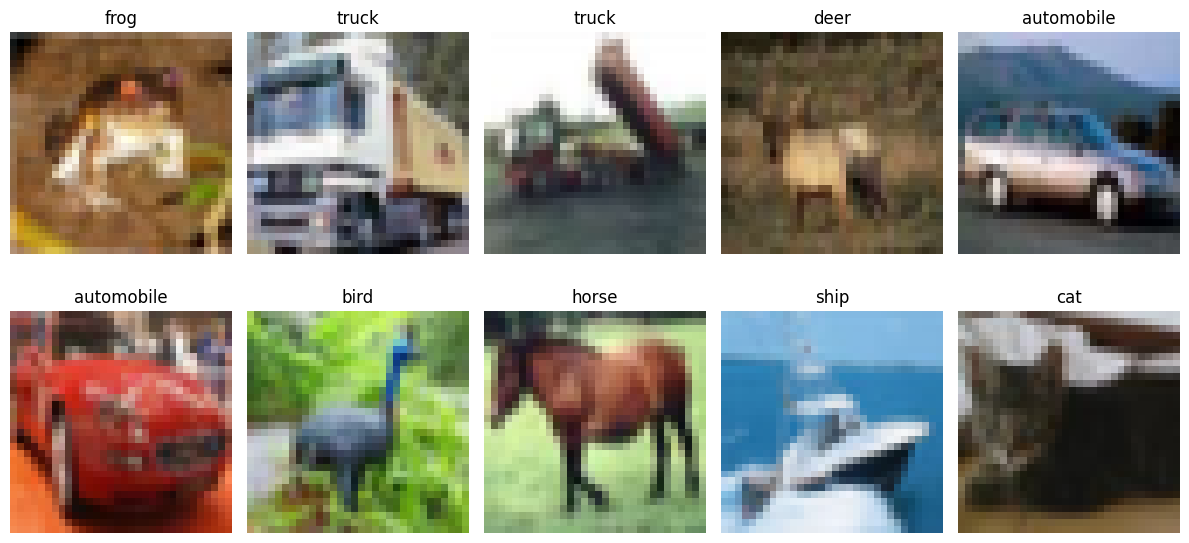

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    image, label = train_dataset[i]

    # Convert (C, H, W) -> (H, W, C)
    image = image.permute(1, 2, 0)

    ax = axes[i // 5, i % 5]   # Select subplot

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
image, label = train_dataset[6]
print("Image Label: ", train_dataset.classes[label])
print("Shape: ", image.shape)
print("Dtyle: ", image.dtype)

Image Label:  bird
Shape:  torch.Size([3, 32, 32])
Dtyle:  torch.float32


In [13]:
print(image) # transforms kamal

tensor([[[0.6431, 0.4118, 0.4627,  ..., 0.4275, 0.4235, 0.3569],
         [0.6549, 0.4549, 0.2824,  ..., 0.4118, 0.4118, 0.3490],
         [0.5490, 0.5569, 0.4667,  ..., 0.4078, 0.3294, 0.3059],
         ...,
         [0.5451, 0.5569, 0.5294,  ..., 0.3490, 0.3804, 0.4941],
         [0.6392, 0.6000, 0.5725,  ..., 0.3333, 0.3843, 0.4980],
         [0.7176, 0.6902, 0.6039,  ..., 0.3686, 0.3569, 0.4784]],

        [[0.8078, 0.5490, 0.5804,  ..., 0.5765, 0.5765, 0.5059],
         [0.8353, 0.6275, 0.4275,  ..., 0.5569, 0.5569, 0.4980],
         [0.7490, 0.7569, 0.6392,  ..., 0.5451, 0.4706, 0.4510],
         ...,
         [0.5804, 0.6078, 0.6118,  ..., 0.5255, 0.5804, 0.6902],
         [0.6157, 0.6431, 0.6431,  ..., 0.5098, 0.5804, 0.6980],
         [0.6000, 0.7137, 0.6039,  ..., 0.5255, 0.5216, 0.6667]],

        [[0.3294, 0.2392, 0.3961,  ..., 0.2863, 0.2706, 0.2235],
         [0.3294, 0.1922, 0.1686,  ..., 0.3098, 0.2824, 0.2235],
         [0.2549, 0.2588, 0.3098,  ..., 0.3294, 0.2275, 0.

In [14]:
red = image[0]
green = image[1]
blue = image[2]

print("Red Shape   :", red.shape)
print("Green Shape :", green.shape)
print("Blue Shape  :", blue.shape)

Red Shape   : torch.Size([32, 32])
Green Shape : torch.Size([32, 32])
Blue Shape  : torch.Size([32, 32])


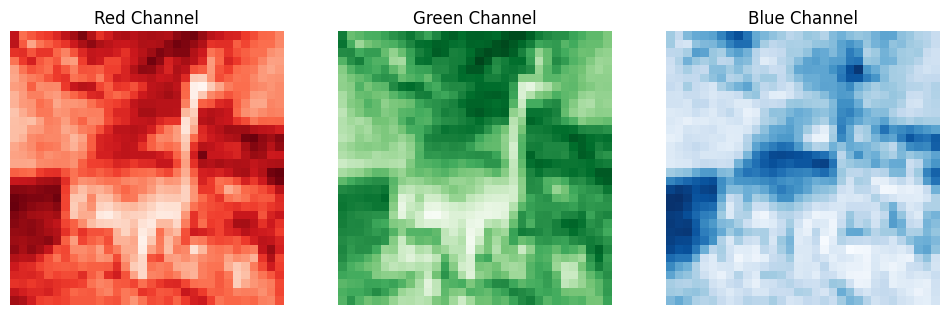

In [15]:
fig, ax = plt.subplots(1,3,figsize=(12,4))

ax[0].imshow(red, cmap="Reds")
ax[0].set_title("Red Channel")
ax[0].axis("off")

ax[1].imshow(green, cmap="Greens")
ax[1].set_title("Green Channel")
ax[1].axis("off")

ax[2].imshow(blue, cmap="Blues")
ax[2].set_title("Blue Channel")
ax[2].axis("off")

plt.show()

In [16]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [18]:
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [19]:
print("="*50)

In [20]:
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=3,
    stride=1,
    padding=1
)

In [21]:
print(conv1)

Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [22]:
feature_map = conv1(images)
feature_map.shape

torch.Size([64, 32, 32, 32])

In [23]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # ---------Block1--------
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
    
            #----------Block2--------
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
    
            #----------Block3--------
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
    
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128*4*4, out_features=512),
            nn.ReLU(),
            nn.Linear(in_features=512, out_features=256),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(in_features=256, out_features=10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [24]:
model = MyCNN().to(device)

In [25]:
model

MyCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_

In [26]:
images, labels = next(iter(train_loader))
images = images.to(device)
output = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", output.shape)

Input Shape : torch.Size([64, 3, 32, 32])
Output Shape: torch.Size([64, 10])


In [27]:
x = images

print("Input :", x.shape)

for layer in model.features:
    x = layer(x)
    print(f"{layer.__class__.__name__} -> {x.shape}")
    print()

for layer in model.classifier:
    x = layer(x)
    print(f"{layer.__class__.__name__} -> {x.shape}")
    print()

Input : torch.Size([64, 3, 32, 32])
Conv2d -> torch.Size([64, 32, 32, 32])

BatchNorm2d -> torch.Size([64, 32, 32, 32])

ReLU -> torch.Size([64, 32, 32, 32])

MaxPool2d -> torch.Size([64, 32, 16, 16])

Conv2d -> torch.Size([64, 64, 16, 16])

BatchNorm2d -> torch.Size([64, 64, 16, 16])

ReLU -> torch.Size([64, 64, 16, 16])

MaxPool2d -> torch.Size([64, 64, 8, 8])

Conv2d -> torch.Size([64, 128, 8, 8])

BatchNorm2d -> torch.Size([64, 128, 8, 8])

ReLU -> torch.Size([64, 128, 8, 8])

MaxPool2d -> torch.Size([64, 128, 4, 4])

Flatten -> torch.Size([64, 2048])

Linear -> torch.Size([64, 512])

ReLU -> torch.Size([64, 512])

Linear -> torch.Size([64, 256])

ReLU -> torch.Size([64, 256])

Dropout -> torch.Size([64, 256])

Linear -> torch.Size([64, 10])



In [28]:
tol_param = sum(p.numel() for p in model.parameters())
trn_param = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {tol_param:,}")
print(f"Trainable parameters: {trn_param:,}")

Total parameters: 1,276,682
Trainable parameters: 1,276,682


In [29]:
criterion = nn.CrossEntropyLoss()

In [30]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)

In [31]:
print("Loss Function :", criterion)
print("Optimizer     :", optimizer)

Loss Function : CrossEntropyLoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [33]:
model.train()
EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/20] | Loss: 1.3343 | Accuracy: 51.60%
Epoch [2/20] | Loss: 0.9331 | Accuracy: 67.60%
Epoch [3/20] | Loss: 0.7642 | Accuracy: 73.64%
Epoch [4/20] | Loss: 0.6627 | Accuracy: 77.43%
Epoch [5/20] | Loss: 0.5800 | Accuracy: 80.15%
Epoch [6/20] | Loss: 0.5019 | Accuracy: 82.66%
Epoch [7/20] | Loss: 0.4422 | Accuracy: 84.71%
Epoch [8/20] | Loss: 0.3865 | Accuracy: 86.69%
Epoch [9/20] | Loss: 0.3333 | Accuracy: 88.60%
Epoch [10/20] | Loss: 0.2820 | Accuracy: 90.37%
Epoch [11/20] | Loss: 0.2498 | Accuracy: 91.41%
Epoch [12/20] | Loss: 0.2092 | Accuracy: 92.73%
Epoch [13/20] | Loss: 0.1827 | Accuracy: 93.72%
Epoch [14/20] | Loss: 0.1671 | Accuracy: 94.33%
Epoch [15/20] | Loss: 0.1392 | Accuracy: 95.25%
Epoch [16/20] | Loss: 0.1332 | Accuracy: 95.45%
Epoch [17/20] | Loss: 0.1196 | Accuracy: 95.74%
Epoch [18/20] | Loss: 0.1062 | Accuracy: 96.46%
Epoch [19/20] | Loss: 0.1010 | Accuracy: 96.61%
Epoch [20/20] | Loss: 0.0971 | Accuracy: 96.76%


In [34]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, dim=1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 76.50%


In [39]:
classes = train_dataset.classes

images, labels = next(iter(test_loader))

images = images.to(device)

model.eval()

with torch.no_grad():

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

In [40]:
images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

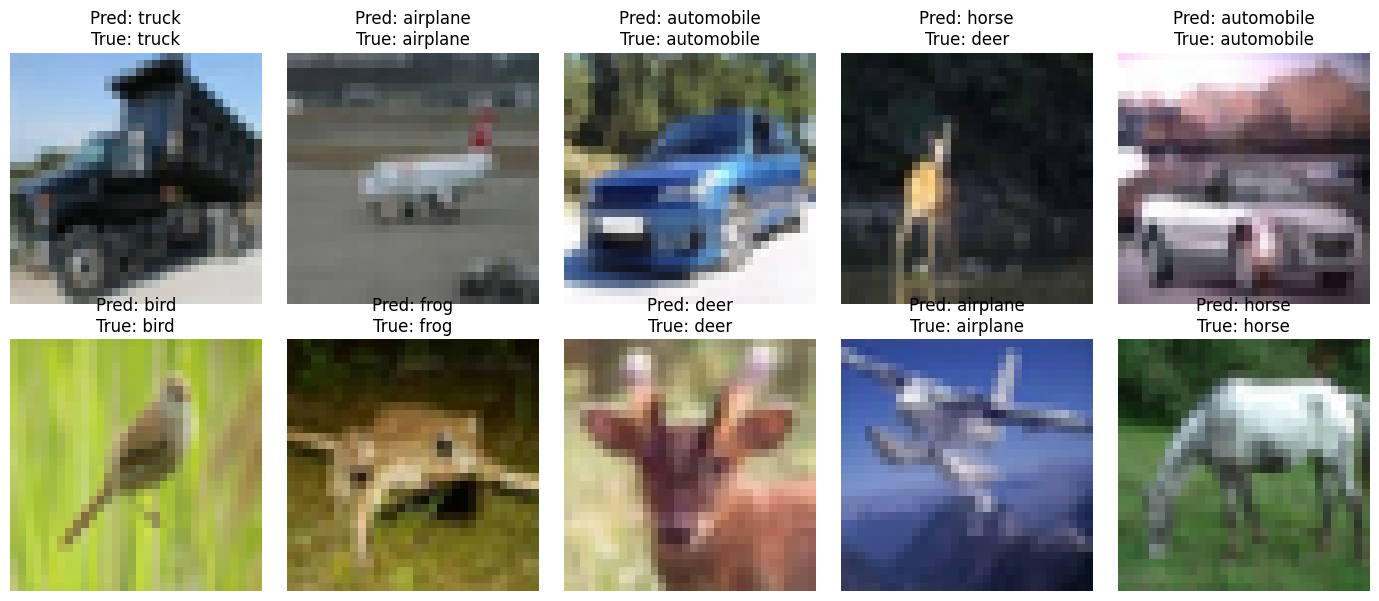

In [41]:
fig, axes = plt.subplots(2,5, figsize=(14,6))

for i, ax in enumerate(axes.flat):

    image = images[i].permute(1,2,0)

    ax.imshow(image)

    ax.set_title(
        f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}"
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

In [42]:
from sklearn.metrics import confusion_matrix

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        all_predictions.extend(predicted.cpu().numpy())

        all_labels.extend(labels.numpy())

In [43]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

cm

array([[781,  11,  31,  58,  28,   5,   4,   8,  17,  57],
       [ 12, 874,   2,  11,   1,   9,   1,   0,   8,  82],
       [ 54,   4, 582, 143,  87,  63,  29,  21,   4,  13],
       [ 10,   5,  19, 729,  51, 137,  15,  20,   0,  14],
       [  9,   3,  29, 117, 750,  34,  11,  42,   1,   4],
       [  6,   2,   9, 217,  37, 685,   5,  33,   0,   6],
       [ 10,   2,  19, 146,  30,  26, 753,   5,   1,   8],
       [ 13,   0,   4,  55,  46,  46,   1, 819,   0,  16],
       [ 55,  31,   7,  48,  12,   4,   2,   5, 787,  49],
       [ 15,  40,   3,  25,   3,   7,   2,   5,  10, 890]])

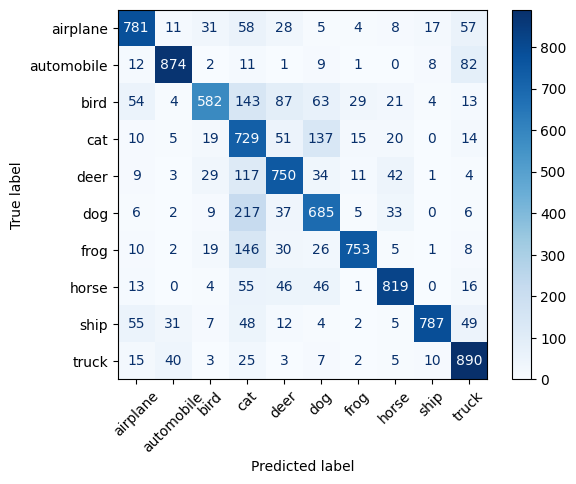

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.show()

In [47]:
import os
os.makedirs(name="my-cnn", exist_ok=True)

In [49]:
torch.save(model.state_dict(), "my-cnn/cifar-cnn-model.bin")

In [51]:
config = {
    "model": "MyCNN",
    "dataset": "CIFAR-10",
    "num_classes": 10
}

import json

with open("my-cnn/config.json", "w") as f:
    json.dump(config, f, indent=4)

In [52]:
labels = train_dataset.classes

with open("my-cnn/labels.json", "w") as f:
    json.dump(labels, f, indent=4)

In [53]:
readme = """
# MyCNN CIFAR-10

A CNN trained from scratch on CIFAR-10 using PyTorch.

## Dataset
- CIFAR-10

## Architecture
- Conv-BN-ReLU-MaxPool
- Conv-BN-ReLU-MaxPool
- Conv-BN-ReLU-MaxPool
- Fully Connected Layers

## Framework
PyTorch
"""

with open("my-cnn/README.md", "w") as f:
    f.write(readme)

In [54]:
from huggingface_hub import HfApi
api=HfApi()

In [56]:
api.create_repo(repo_id="aijadugar/cifar-10-cnn", token="xxx", exist_ok=True)
api.upload_folder(repo_id="aijadugar/cifar-10-cnn", folder_path="/kaggle/working/my-cnn", commit_message="simple cnn by pytorch-cuda", token="xxx", repo_type='model')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:10908: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/aijadugar/cifar-10-cnn/commit/11f312489ee2dcfdd6c54dea41808fb8e42aad7d', commit_message='simple cnn by pytorch-cuda', commit_description='', oid='11f312489ee2dcfdd6c54dea41808fb8e42aad7d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aijadugar/cifar-10-cnn', endpoint='https://huggingface.co', repo_type='model', repo_id='aijadugar/cifar-10-cnn'), pr_revision=None, pr_num=None)